### Projektovanje nelinearnog filtera: Medijanski filtar

**Kakav je to filter?**
Medijanski filter pripada klasi **nelinearnih digitalnih filtara**. Za razliku od linearnih FIR i IIR filtara koji koriste matematičku operaciju konvolucije, medijanski filtar funkcioniše na principu sortiranja. On posmatra klizni "prozor" (određeni neparan broj susednih uzoraka u signalu), sortira te vrednosti po veličini od najmanje do najveće, i kao izlaznu vrednost jednostavno usvaja onu koja se nalazi tačno u sredini sortiranog niza (medijanu).

**Motivacija za izbor:**
Ovaj filtar je odabran jer predstavlja **najefikasnije rešenje za eliminaciju impulsnog šuma** (ekstremnih pikova sa ultrazvučnog senzora) u sistemima autonomne vožnje. 
* **Potpuno ignorisanje ekstrema:** Pošto filtar bira središnju vrednost, nerealno visoki ili nerealno niski pikovi će prilikom sortiranja uvek završiti na samim krajevima niza i biće potpuno odbačeni. Filtar ih ne "razmazuje" niti stvara odloženo "zvonjenje" u sistemu.
* **Očuvanje oštrih ivica (step promena):** Ako se stvarna udaljenost skokovito promeni (npr. ispred vozila iznenada iskoči nova prepreka), medijanski filtar neće veštački "umekšati" taj prelaz kao što bi to uradio niskopropusni filtar, već će zadržati oštrinu promene, omogućavajući trenutnu reakciju kontrolera.

**Kompromisi koje ovaj filtar nosi:**
Iako je superioran u borbi protiv impulsnog šuma, medijanski filtar nosi nekoliko značajnih nedostataka:
1. **Slabo gušenje kontinualnog (Gausovog) šuma:** Medijanski filtar nije dizajniran da "pegla" sitne merne varijacije. Ako se primeni samo on, glavni trend signala će i dalje ostati blago nazubljen i hrapav.
2. **Gubitak frekvencijske analize:** Zbog njegove nelinearne prirode, ne važe klasični alati spektralne analize. Ne možemo mu izračunati prenosnu funkciju, niti definisati jasnu amplitudsku i faznu karakteristiku ili konstantno grupno kašnjenje kao kod FIR filtra.
3. **Procesorska zahtevnost:** Algoritmi za sortiranje niza podataka zahtevaju više procesorskog vremena i memorije u mikrokontroleru u poređenju sa jednostavnim množenjem i sabiranjem, posebno ako se izabere dugačak "prozor" filtra.

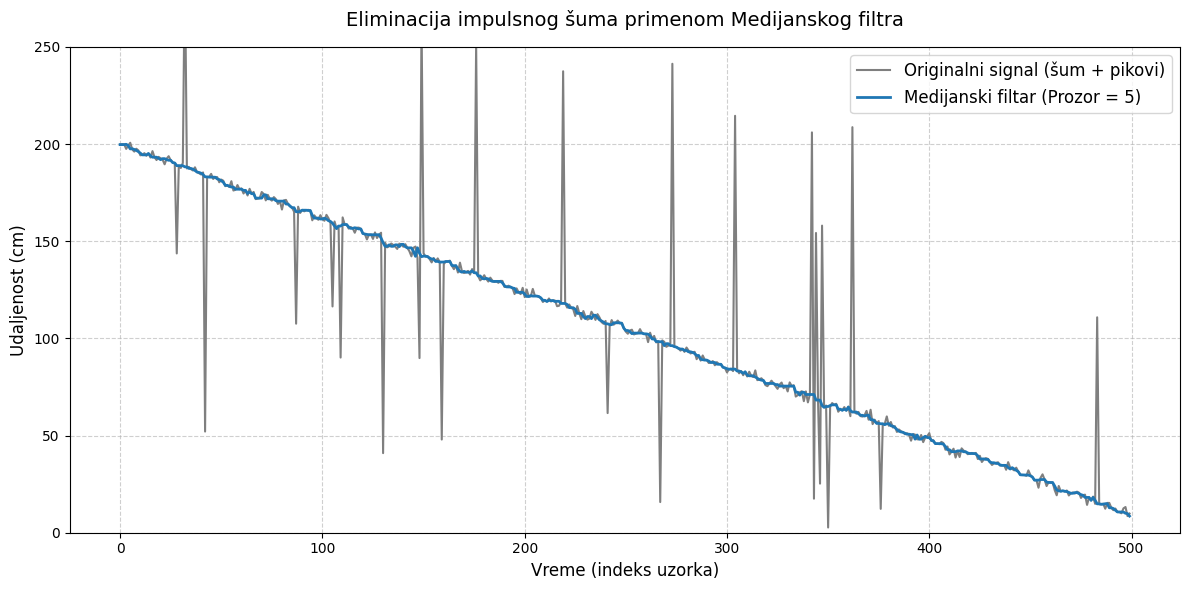

In [2]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt
import pandas as pd

# Učitavanje podataka iz CSV fajla
df = pd.read_csv('ultrazvucni_signal.csv')

# 1. Definisanje parametara medijanskog filtra
velicina_prozora = 5  # Mora biti neparan broj (npr. 3, 5, 7)

# 2. Primena medijanskog filtra na originalni signal
medijan_filtriran = signal.medfilt(df['Udaljenost_cm'], kernel_size=velicina_prozora)

plt.figure(figsize=(12, 6))

plt.plot(df['Vreme_indeks'], df['Udaljenost_cm'], color="tab:gray", label='Originalni signal (šum + pikovi)')

# Crtamo medijan filtriran signal
plt.plot(df['Vreme_indeks'], medijan_filtriran, color="tab:blue", linewidth=2, label=f'Medijanski filtar (Prozor = {velicina_prozora})')

plt.title('Eliminacija impulsnog šuma primenom Medijanskog filtra', fontsize=14, pad=15)
plt.xlabel('Vreme (indeks uzorka)', fontsize=12)
plt.ylabel('Udaljenost (cm)', fontsize=12)

plt.ylim(0, 250) 
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

### Parametar medijanskog filtra: Veličina prozora (Kernel Size)

**Šta predstavlja veličina prozora?**
Veličina prozora (ili *kernel size*) definiše broj susednih odbiraka (uzoraka) koje algoritam posmatra u jednom trenutku kako bi odredio izlaznu vrednost. Prozor "klizi" duž celog vremenskog niza, uzimajući trenutni odbirak zajedno sa određenim brojem njegovih levih (prošlih) i desnih (budućih) suseda, sortira ih po veličini i bira središnju vrednost.

**Zašto mora biti neparan broj?**
Veličina prozora se uvek bira kao neparan broj (npr. 3, 5, 7, 9). Razlog leži u tome što je medijana po definiciji vrednost koja se nalazi tačno na sredini sortiranog niza.
* Kada je niz **neparan** (npr. 5 elemenata), uvek postoji tačno jedan centralni element (treći po redu). Taj element je uvek **stvarni, fizički očitani podatak** sa senzora.
* Da je prozor **paran** (npr. 4 elementa), ne bi postojao jedan centralni broj. Algoritam bi morao da izračuna aritmetičku sredinu dva središnja elementa. To bi značilo uvođenje **linearnog** usrednjavanja (koje je osetljivo na ekstremne vrednosti).

**Kako se bira i kako promena utiče na izlaz?**
Pravilo za odabir direktno zavisi od "širine" impulsnog šuma. Da bi medijanski filtar uspešno uklonio neželjeni pik, više od polovine uzoraka unutar prozora moraju biti "ispravni" podaci. Dakle, ako u najgorem slučaju očekujemo da ultrazvučni senzor napravi 2 uzastopne greške, prozor mora biti barem veličine 5.

Uticaj promene veličine prozora:
* **Mali prozor (npr. $N=3$):** Najmanje opterećuje procesor i najbolje čuva stvarne, oštre promene u korisnom signalu. Međutim, ako senzor napravi seriju od dve ili više uzastopnih grešaka, mali prozor neće moći da ih eliminiše i pik će ostati prisutan u izlaznom signalu.
* **Veliki prozor (npr. $N=15$ ili veći):** Izuzetno je robustan i garantovano će obrisati i najšire grupe lažnih očitavanja. Ipak, ovaj izbor nosi ozbiljne kompromise: veliki prozor počinje da odseca i "spljoštava" stvarne vrhove korisnog signala i značajno povećava vreme izvršavanja na mikrokontroleru zbog potrebe za sortiranjem dugačkih nizova brojeva.

### Karakterizacija medijanskog filtra (Odsustvo frekvencijske analize)

Za razliku od prethodno dizajniranih FIR i IIR filtara, za medijanski filtar **nije moguće** prikazati grafike položaja nula i polova, amplitudske i fazne karakteristike, niti grupnog kašnjenja.

**Objašnjenje:**
Alati za frekvencijsku analizu su matematički definisani isključivo za linearne vremenski invarijantne (LTI) sisteme koji se mogu opisati prenosnom funkcijom $H(z)$ i diferencijalnim jednačinama sa konstantnim koeficijentima. Medijanski filtar je **nelinearan sistem** baziran na logičkoj operaciji sortiranja niza vrednosti. 

Pošto se ne zasniva na operaciji konvolucije, njegov odziv ne zavisi samo od frekvencije signala, već direktno od oblika i amplitude samih podataka. Zbog toga, klasična Bodeova analiza u frekvencijskom domenu za ovaj filtar ne postoji, te se njegova analiza vrši isključivo posmatranjem odziva u vremenskom domenu (npr. reakcija na step funkciju i impuls).

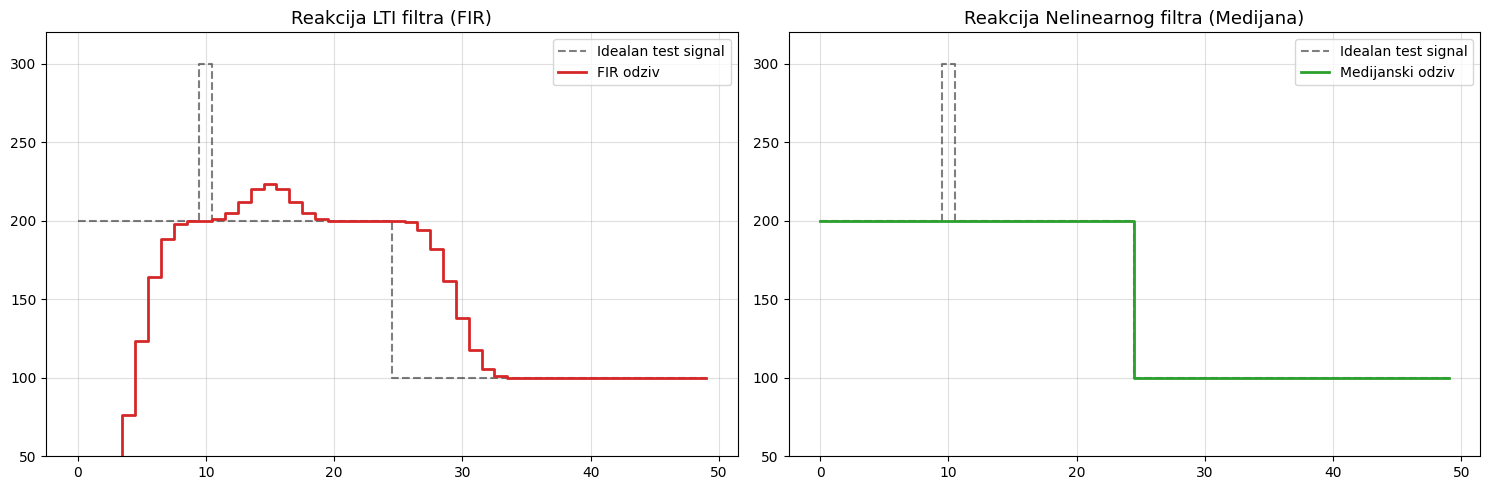

In [3]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt


# 1. Kreiranje test signala: Step funkcija + Impuls
# Zamišljamo da je robot išao ka prepreci, i da je prepreka iznenada "skočila" bliže (step)
# a uz to je senzor napravio jednu grubu grešku (impuls)
duzina = 50
test_signal = np.ones(duzina) * 200  # Konstantna udaljenost 200 cm
test_signal[25:] = 100               # Nagla promena na 100 cm (Step)
test_signal[10] = 300                # Lažni ekstremni pik (Impuls)


# A) FIR Niskopropusni (N=11 radi lakšeg prikaza)
h_fir = signal.firwin(11, 0.2)
odziv_fir = signal.lfilter(h_fir, 1.0, test_signal)

# B) Medijanski filtar (Prozor = 5)
odziv_medijan = signal.medfilt(test_signal, kernel_size=5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# --- Grafik 1: Ponašanje FIR filtra ---
ax1.plot(test_signal, 'k--', drawstyle='steps-mid', alpha=0.5, label='Idealan test signal')
ax1.plot(odziv_fir, color='tab:red', linewidth=2, drawstyle='steps-mid', label='FIR odziv')
ax1.set_title('Reakcija LTI filtra (FIR)', fontsize=13)
ax1.set_ylim(50, 320)
ax1.legend()
ax1.grid(True, alpha=0.4)

# --- Grafik 2: Ponašanje Medijanskog filtra ---
ax2.plot(test_signal, 'k--', drawstyle='steps-mid', alpha=0.5, label='Idealan test signal')
ax2.plot(odziv_medijan, color='tab:green', linewidth=2, drawstyle='steps-mid', label='Medijanski odziv')
ax2.set_title('Reakcija Nelinearnog filtra (Medijana)', fontsize=13)
ax2.set_ylim(50, 320)
ax2.legend()
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

### Dodatno uglačavanje signala: Filtar pokretnog proseka (Moving Average)

**Kakav je to filtar?**
Filtar pokretnog proseka (Moving Average - MA) je jedan od najjednostavnijih **linearnih digitalnih filtara niske propustljivosti** (suštinski, to je specijalni slučaj FIR filtra sa jednakim težinskim koeficijentima). Njegov princip rada je izuzetno prost: on posmatra klizni "prozor" određene dužine, sabira sve vrednosti unutar tog prozora i računa njihovu prostornu aritmetičku sredinu. Ta izračunata prosečna vrednost postaje novi, isfiltrirani izlazni odbirak. 

**Motivacija za izbor:**
Iako je medijanski filtar u prethodnom koraku savršeno obrisao ekstremne pikove (impulsni šum), naš signal (plava linija na prethodnim graficima) je i dalje ostao blago "čupav" i nazubljen zbog prisustva sitnog, kontinualnog mernog šuma (Gausov šum). 
* **Optimalno ravnanje belog šuma:** Matematički gledano, usrednjavanje je najefikasniji metod za smanjenje varijanse nasumičnog mernog šuma. MA filtar će ove sitne, brze oscilacije efikasno "ispeglati" i rezultovati potpuno glatkom, stabilnom krivom prilaska prepreci.
* **Ekstremna hardverska efikasnost:** Za razliku od složenih Batervortovih ili dugačkih FIR filtara dizajniranih metodom prozora, MA filtar zahteva minimalan broj procesorskih operacija (samo obično sabiranje niza brojeva i jedno deljenje na kraju). Ovo ga čini standardom za implementaciju u realnom vremenu na slabijim mikrokontrolerima u robotici.

**Kompromisi koje ovaj filtar nosi:**
* **Linearno kašnjenje (Group Delay):** Kao i svaki linearni FIR filtar, MA unosi fazno kašnjenje u sistem. Što je prozor za usrednjavanje veći, signal će biti lepši i glađi, ali će informacija o udaljenosti koju kontroler dobija više kasniti za realnim stanjem na terenu.
* **Umekšavanje naglih promena (Slaba prelazna karakteristika):** Ako se stvarna udaljenost naglo i skokovito promeni, MA filtar ne može to da isprati trenutno. On će tu oštru promenu u prostoru (step funkciju) pretvoriti u blagu kosinu, razmazujući je u vremenu.
* **Nesavršena frekvencijska karakteristika:** U frekvencijskom domenu, MA filtar nema strm i oštar prelazni opseg, i propušta dosta energije na višim frekvencijama kroz tzv. bočne latice. Zbog ovoga on **nije dobar izbor za uklanjanje jakih smetnji**, ali je savršen alat za završno "poliranje" signala nakon što je medijanski filtar već očistio glavne anomalije.

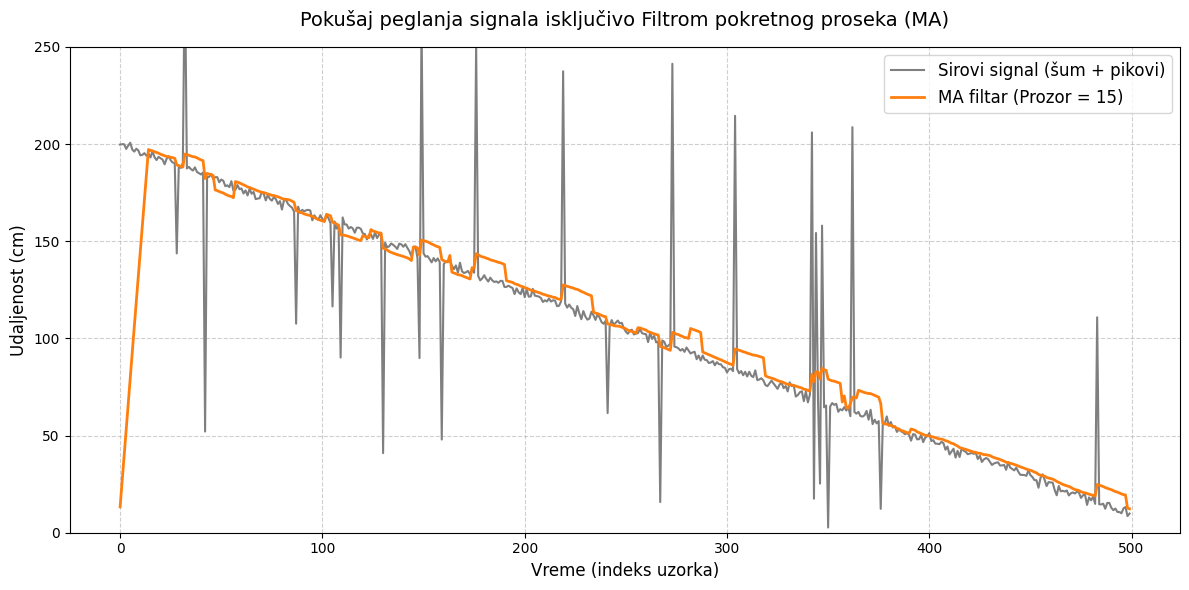

In [4]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt


# 1. Definisanje parametara MA filtra
velicina_prozora_ma = 15  # Dužina prozora za usrednjavanje (N)

# 2. Kreiranje koeficijenata MA filtra
# Svi koeficijenti b su isti i iznose 1/N. a je 1 (nema povratne sprege)
b_ma = np.ones(velicina_prozora_ma) / velicina_prozora_ma
a_ma = 1.0 

# 3. Primena MA filtra na originalni signal (kauzalni odziv sa kašnjenjem)
ma_filtriran = signal.lfilter(b_ma, a_ma, df['Udaljenost_cm'])

# 4. Vizuelizacija rezultata u vremenskom domenu
plt.figure(figsize=(12, 6))

# Originalni signal (šum + pikovi)
plt.plot(df['Vreme_indeks'], df['Udaljenost_cm'], color="tab:gray", label='Sirovi signal (šum + pikovi)')

# MA filtriran signal
plt.plot(df['Vreme_indeks'], ma_filtriran, color='tab:orange', linewidth=2, label=f'MA filtar (Prozor = {velicina_prozora_ma})')

plt.title('Pokušaj peglanja signala isključivo Filtrom pokretnog proseka (MA)', fontsize=14, pad=15)
plt.xlabel('Vreme (indeks uzorka)', fontsize=12)
plt.ylabel('Udaljenost (cm)', fontsize=12)

plt.ylim(0, 250) 
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

### Parametri Filtra pokretnog proseka (MA) i njihov uticaj

Glavni i jedini parametar Filtra pokretnog proseka (MA) je **dužina prozora za usrednjavanje ($N$)**. Ovaj parametar definiše nad koliko susednih odbiraka će se računati aritmetička sredina. Za razliku od medijanskog filtra, ovde dužina prozora **ne mora biti neparan broj**.

Odabir širine prozora $N$ predstavlja kompromis između glatkoće signala i kašnjenja u vremenu:

1. **Glatkoća signala (Smanjenje šuma)**
   * **Mali prozor (npr. $N=3$ do $5$):** Signal će zadržati brz odziv, ali usrednjavanje nad malim brojem uzoraka neće biti dovoljno da značajno smanji varijansu Gausovog mernog šuma. Kriva će ostati blago nazubljena.
   * **Veliki prozor (npr. $N=15$ do $30$):** Što je više uzoraka uključeno u prosek, to se efekat nasumičnog šuma više poništava. Kriva na izlazu će biti izuzetno glatka i stabilna, što je idealno za vizuelizaciju i vođenje vozila pri konstantnoj brzini.

2. **Grupno kašnjenje (Group Delay)**
   * Pošto je MA vrsta FIR filtra sa linearnom fazom, on unosi konstantno grupno kašnjenje koje iznosi tačno $M = (N-1)/2$ odbiraka. 
   * **Uticaj velikog prozora:** Ako izaberemo preveliko $N$ (npr. $N=50$), sistem će odlično očistiti šum, ali će vozilo dobijati informaciju o udaljenosti koja kasni za $25$ odbiraka u odnosu na stvarno vreme (što je više od jedne sekunde pri $20\text{ Hz}$). Za brzo kretanje i kočenje u nuždi, ovo kašnjenje može biti fatalno.

3. **Uticaj na prelazne pojave (Step odziv)**
   * Kada stvarna udaljenost naglo padne (npr. skok sa $200\text{ cm}$ na $100\text{ cm}$), MA filtar tu promenu razmazuje duž celog prozora $N$. Povećanjem prozora, vertikalni pad pretvara se u blagu kosinu, što znači da vozilo postepeno, a ne trenutno, detektuje punu promenu udaljenosti.

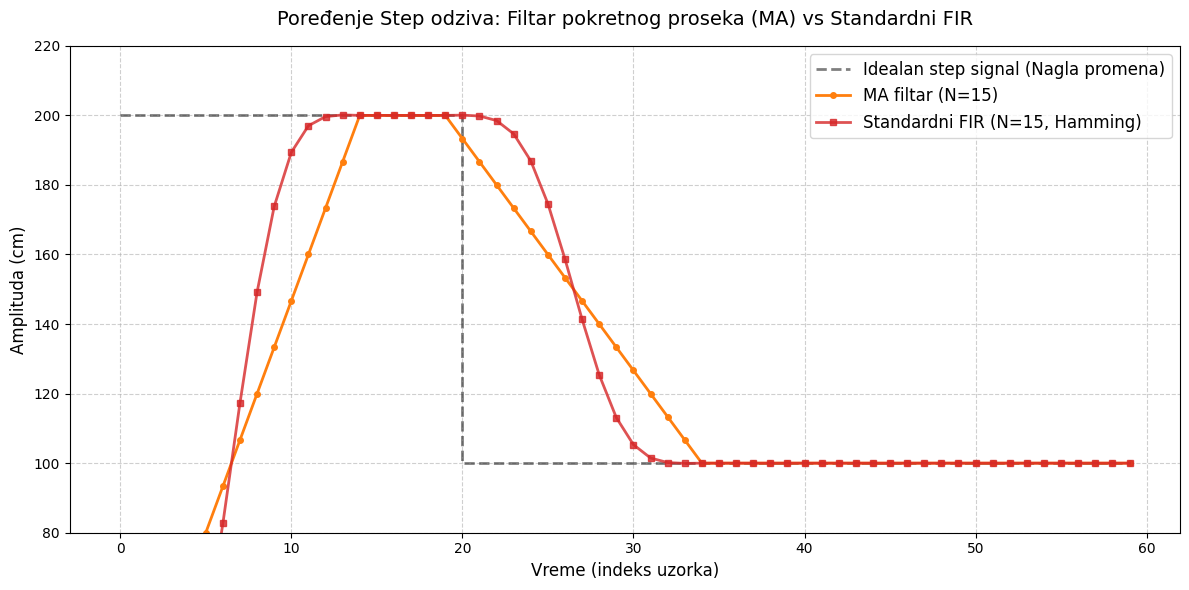

In [ ]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

# --- 1. Kreiranje test signala (Step funkcija) ---
duzina = 60
test_signal = np.ones(duzina) * 200  # Konstantna udaljenost 200 cm
test_signal[20:] = 100               # Nagla promena na 100 cm (Step)

# --- 2. Parametri filtara ---
N_taps = 15  # Koristimo isti broj koeficijenata za oba filtra radi poređenja

# A) MA filtar (Svi koeficijenti su isti: 1/N)
b_ma = np.ones(N_taps) / N_taps
odziv_ma = signal.lfilter(b_ma, 1.0, test_signal)

# B) Standardni FIR NF filtar (Hamingov prozor)
# Bira se relativno niska granična učestanost da bi bio uporediv sa MA filtrom
cutoff = 0.15 
h_fir = signal.firwin(N_taps, cutoff, window='hamming')
odziv_fir = signal.lfilter(h_fir, 1.0, test_signal)

# --- 3. Vizuelizacija rezultata ---
plt.figure(figsize=(12, 6))

# Idealan signal
plt.plot(test_signal, 'k--', drawstyle='steps-post', alpha=0.5, linewidth=2, label='Idealan step signal (Nagla promena)')

# MA filtar
plt.plot(odziv_ma, color='tab:orange', marker='o', markersize=4, linewidth=2, label=f'MA filtar (N={N_taps})')

# Standardni FIR filtar
plt.plot(odziv_fir, color='tab:red', marker='s', markersize=4, linewidth=2, alpha=0.8, label=f'Standardni FIR (N={N_taps}, Hamming)')

plt.title('Poređenje Step odziva: Filtar pokretnog proseka (MA) vs Standardni FIR', fontsize=14, pad=15)
plt.xlabel('Vreme (indeks uzorka)', fontsize=12)
plt.ylabel('Amplituda (cm)', fontsize=12)

plt.ylim(80, 220)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

### Analiza prelazne pojave (Step odziv)

Grafik step odziva nam prikazuje kako se različiti linearni filtri ponašaju kada na ulazu dobiju naglu promenu signala. Iako oba posmatrana filtra imaju istu dužinu prozora  ($N=15$), njihov odziv se drastično razlikuje zbog načina na koji raspoređuju "težine" nad uzorcima:

1. **Odziv MA filtra (Narandžasta linija - "Rampa")**
   * **Ponašanje:** MA filtar promenu realizuje kao savršeno ravnu kosinu (linearnu rampu). On najbrže počinje da obara vrednost signala, ali stvara oštre "ćoškove" na početku i na kraju prelaznog procesa.
   * **Zašto se to dešava:** Zato što su svi koeficijenti MA filtra potpuno jednaki ($1/N$). Svaki novi odbirak koji uđe u prozor doprinosi promeni izlaza za potpuno isti, konstantan iznos.

2. **Odziv standardnog FIR filtra (Crvena linija - "S-kriva")**
   * **Ponašanje:** FIR filtar (dizajniran Hamingovim prozorom) promenu realizuje u obliku glatke "S" krive. Reakcija je u početku sporija, zatim naglo ubrzava u sredini, i na kraju ponovo usporava kako bi "mekano" i asimptotski prišao novoj vrednosti.
   * **Zašto se to dešava:** Hamingov prozor dodeljuje najveće težinske koeficijente uzorcima koji su u samom centru prozora, dok uzorci na ivicama imaju vrlo malu težinu. Zbog toga se najveći deo promene dešava tek kada skok (step) stigne do sredine filtra.

**Zaključak za naš sistem:** Standardni FIR filtar daje prirodniji i glatkiji prelaz, što je povoljnije za mehaniku vozila (izbegavaju se nagli trzaji). Međutim, s obzirom na to da smo u našem sistemu već primenili Medijanski filtar koji savršeno čuva oštre promene i eliminiše glavne anomalije, možemo prihvatiti linearnu "rampu" MA filtra. Njegova ekstremna hardverska efikasnost i jednostavnost računanja čine ga idealnim kompromisom za završno uglačavanje preostalog Gausovog šuma.

### Frekvencijska karakterizacija Filtra pokretnog proseka (MA)

Pošto je MA filtar vrsta linearnog FIR filtra, možemo ga u potpunosti matematički opisati. Njegova specifičnost je u tome što su svi njegovi koeficijenti brojioca međusobno jednaki i iznose 1/N, dok povratne sprege nema. 

Sledeći kod vizuelizuje karakteristike MA filtra sa širinom prozora N = 15. Posebnu pažnju treba obratiti na amplitudsku karakteristiku i položaj nula.

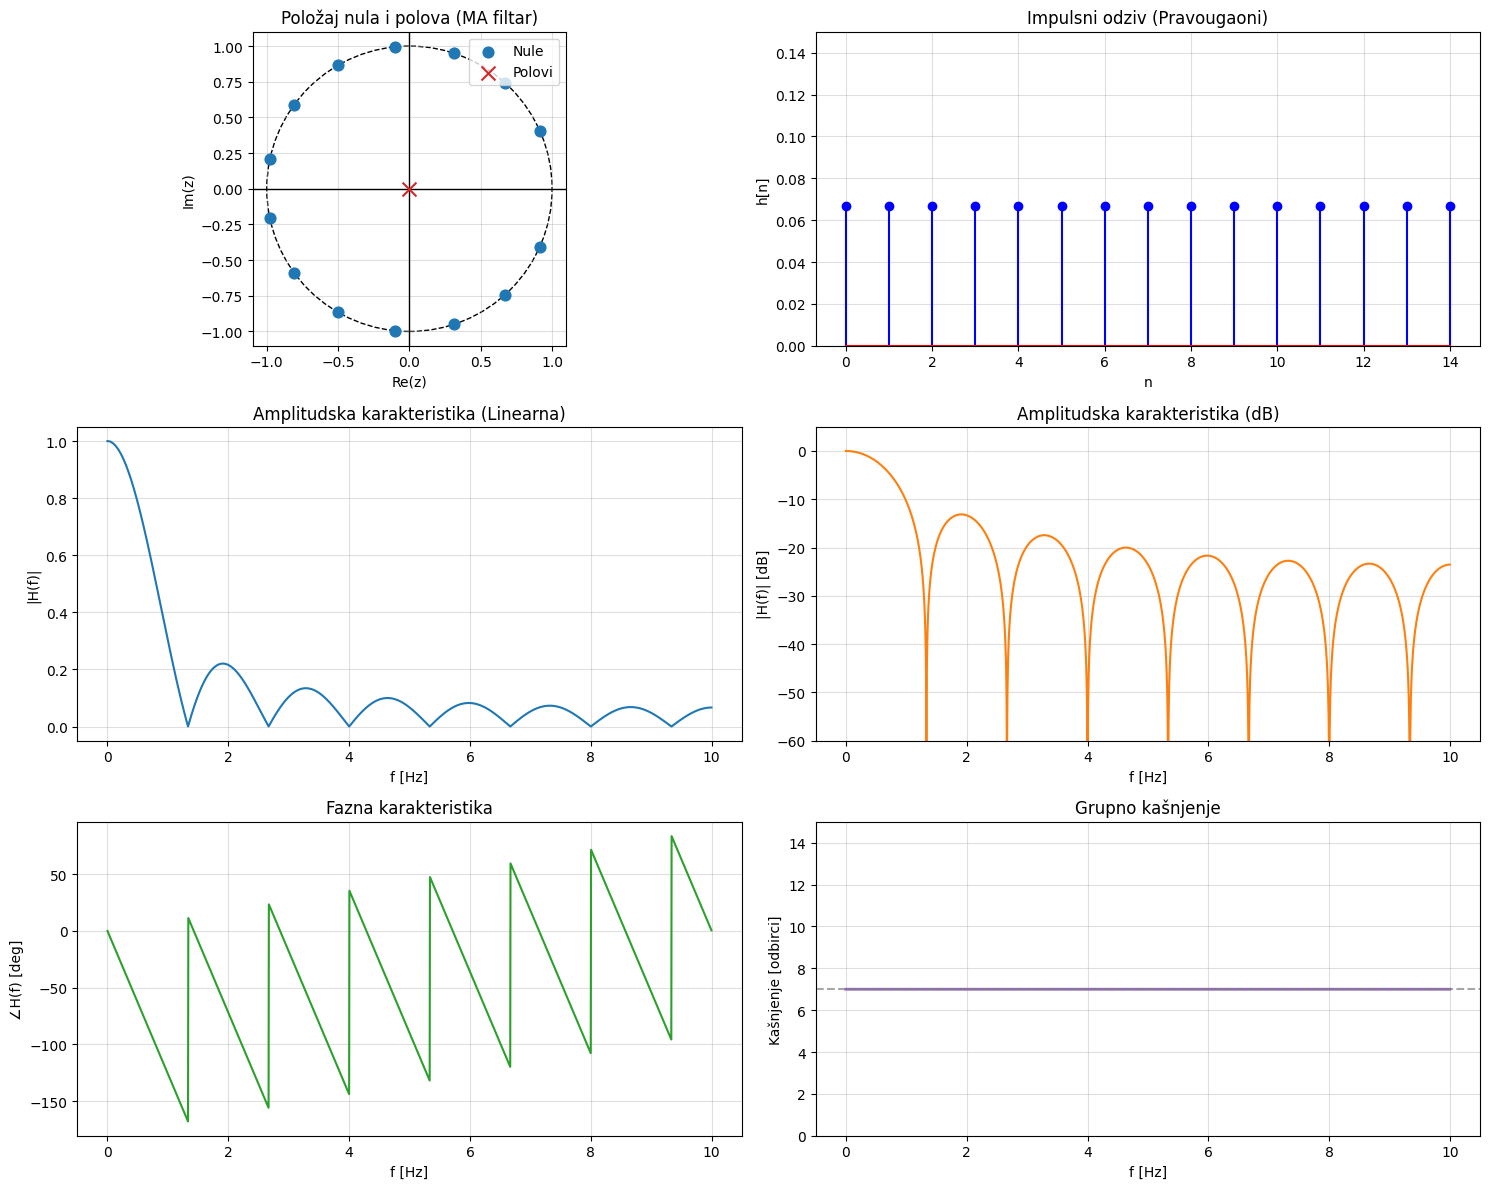

In [7]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# 1. Parametri MA filtra 
fs = 20.0       # Frekvencija odabiranja (Hz)
N_ma = 15       # Dužina prozora za MA filtar

# Koeficijenti MA filtra: niz od N_ma elemenata, gde je svaki 1/N_ma
b_ma = np.ones(N_ma) / N_ma
a_ma = 1.0      # Nema povratne sprege (imenioc je 1)

fig, axs = plt.subplots(3, 2, figsize=(15, 12))
axs = axs.flatten()

# 2. Položaj nula i polova
# Polovi su u koordinatnom početku, a nule računamo iz koeficijenata b_ma
nule_ma = np.roots(b_ma)

jedinicni_krug = Circle((0,0), 1, color='black', fill=False, linestyle='--')
axs[0].add_patch(jedinicni_krug)
axs[0].axvline(0, color='black', lw=1)
axs[0].axhline(0, color='black', lw=1)

axs[0].scatter(np.real(nule_ma), np.imag(nule_ma), marker='o', color='tab:blue', s=60, label='Nule', zorder=3)
axs[0].scatter(0, 0, marker='x', color='tab:red', s=100, label='Polovi', zorder=3) 

axs[0].set_title('Položaj nula i polova (MA filtar)')
axs[0].set_xlabel('Re(z)')
axs[0].set_ylabel('Im(z)')
axs[0].legend()
axs[0].grid(True, alpha=0.4)
axs[0].set_aspect('equal')

# 3. Impulsni odziv h[n]
n_osa = np.arange(N_ma)
axs[1].stem(n_osa, b_ma, basefmt="r-", linefmt="b-", markerfmt="bo")

axs[1].set_title('Impulsni odziv (Pravougaoni)')
axs[1].set_xlabel('n')
axs[1].set_ylabel('h[n]')
# Svi koeficijenti su isti, pa je impulsni odziv ravan
axs[1].set_ylim(0, 0.15)
axs[1].grid(True, alpha=0.4)

# Izračunavanje frekvencijskog odziva 
w_ma, H_ma = signal.freqz(b_ma, a_ma, worN=2048, fs=fs)

# 4. Amplitudska karakteristika (Linearna osa)
axs[2].plot(w_ma, np.abs(H_ma), color='tab:blue') 
axs[2].set_title('Amplitudska karakteristika (Linearna)')
axs[2].set_xlabel('f [Hz]')
axs[2].set_ylabel('|H(f)|')
axs[2].grid(True, alpha=0.4)

# 5. Amplitudska karakteristika (u decibelima - dB)
H_ma_dB = 20 * np.log10(np.abs(H_ma) + 1e-12) 

axs[3].plot(w_ma, H_ma_dB, color='tab:orange') 
axs[3].set_title('Amplitudska karakteristika (dB)')
axs[3].set_xlabel('f [Hz]')
axs[3].set_ylabel('|H(f)| [dB]')
axs[3].grid(True, alpha=0.4)
axs[3].set_ylim(-60, 5) 

# 6. Fazna karakteristika 
faza_ma = np.unwrap(np.angle(H_ma)) * (180 / np.pi) 

axs[4].plot(w_ma, faza_ma, color='tab:green') 
axs[4].set_title('Fazna karakteristika')
axs[4].set_xlabel('f [Hz]')
axs[4].set_ylabel('∠H(f) [deg]')
axs[4].grid(True, alpha=0.4)

# 7. Grupno kašnjenje (Group Delay)
w_gd_ma, gd_ma = signal.group_delay((b_ma, a_ma), w=2048, fs=fs)

axs[5].plot(w_gd_ma, gd_ma, color='tab:purple', linewidth=2) 
axs[5].set_title('Grupno kašnjenje')
axs[5].set_xlabel('f [Hz]')
axs[5].set_ylabel('Kašnjenje [odbirci]')

# Kod MA filtra grupno kašnjenje je (N-1)/2. Za N=15, to je 7.
M_ma = (N_ma - 1) / 2
axs[5].axhline(M_ma, color='gray', linestyle='--', alpha=0.7)
axs[5].set_ylim(0, 15)
axs[5].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

### Analiza karakteristika MA filtra

Dobijeni grafici objašnjavaju prednosti i mane Filtra pokretnog proseka (MA):

1. **Položaj polova i nula:**
   * **Polovi:** Kao i kod svih klasičnih FIR filtara, svi polovi (njih $N-1$) nalaze se u samom koordinatnom početku ($z=0$), što znači da je sistem bezuslovno stabilan.
   * **Nule:** Ravnomerno su raspoređene po ivici jediničnog kruga. 

2. **Impulsni odziv:**
   Očekivano, oblik je potpuno pravougaoni. Svi koeficijenti imaju identičnu vrednost od $1/15$, što potvrđuje da nema naglašavanja središnjih odbiraka kao što je to slučaj kod Hamingovog prozora.

3. **Amplitudska karakteristika (Curenje spektra):**
   Ovo je najveća mana MA filtra. Grafik pokazuje glavni centralni luk (propusni opseg), ali i izražene **bočne lukove**. Prvi bočni luk u nepropusnom opsegu (na grafiku u dB) ima prigušenje od samo $-13\text{ dB}$. To znači da MA filtar prilično slabo blokira visokofrekventni šum, i zbog toga **ne može da posluži kao primarni filtar** za teške smetnje, već isključivo kao alat za fino uglačavanje.

4. **Faza i grupno kašnjenje:**
   Faza strogo linearno opada, a grupno kašnjenje je konstantna horizontalna linija na tačno $7$ odbiraka (što je $(15-1)/2$). Ovo je odlična vest za naš sistem upravljanja, jer garantuje da filtar neće uneti nikakvo fazno izobličenje u kretanje vozila, već samo predvidivo, linearno pomeranje u vremenu.

### Finalno rešenje: Kaskadni filtar (Medijana + Moving Average)

Da bi se dobio idealno čist i pouzdan signal za algoritam upravljanja vozilom, dizajnirana je kaskadna arhitektura procesiranja. 

Redosled filtriranja je strogo definisan prirodom smetnji:
1. **Stepen 1 (Uklanjanje anomalija):** Sirovi signal prvo prolazi kroz **Medijanski filtar** (prozor $N=5$). Njegov jedini zadatak je da detektuje i potpuno eliminiše impulsni šum (lažne pikove) pre nego što oni poremete dalju obradu.
2. **Stepen 2 (Fino uglačavanje):** Tako očišćen signal prosleđuje se u **Filtar pokretnog proseka - MA** (prozor $N=15$). Pošto su ekstremne vrednosti uklonjene, linearni MA filtar bezbedno usrednjava signal, drastično smanjujući varijansu preostalog Gausovog mernog šuma.

Ovakav pristup kombinuje najbolje osobine oba sveta: otpornost nelinearnog i glatkoću linearnog filtra.

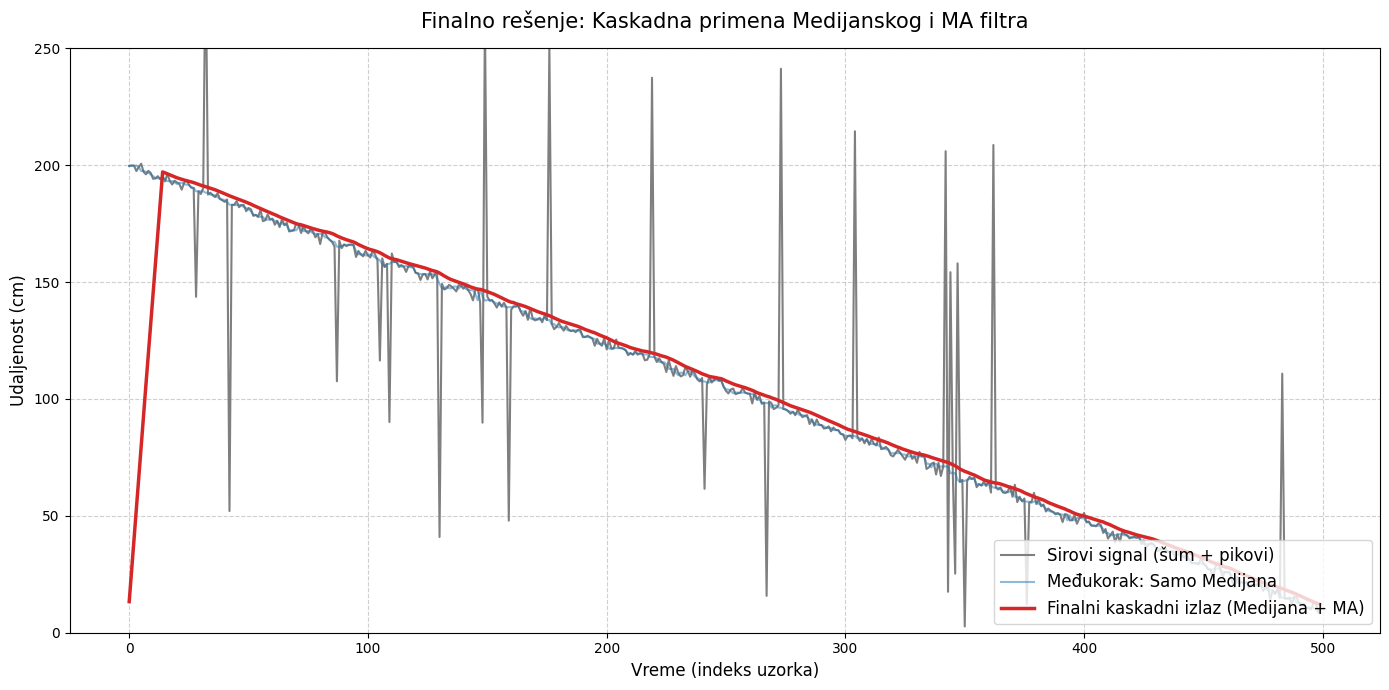

In [11]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt


# --- 1. Parametri filtara ---
prozor_medijane = 5
prozor_ma = 15

# --- 2. KASKADNO FILTRIRANJE ---

# KORAK 1: Originalni signal ulazi u Medijanski filtar
medijan_izlaz = signal.medfilt(df['Udaljenost_cm'], kernel_size=prozor_medijane)

# KORAK 2: Izlaz iz medijane ulazi u MA filtar
b_ma = np.ones(prozor_ma) / prozor_ma

kaskadni_izlaz = signal.lfilter(b_ma, 1.0, medijan_izlaz) 

# --- 3. Vizuelizacija ---
plt.figure(figsize=(14, 7))

plt.plot(df['Vreme_indeks'], df['Udaljenost_cm'], color="tab:gray", linewidth=1.5, label='Sirovi signal (šum + pikovi)')

#  Medijana (plava, međukorak)
plt.plot(df['Vreme_indeks'], medijan_izlaz, color="tab:blue", linewidth=1.5, alpha=0.5, label='Međukorak: Samo Medijana')

#  Kaskada: Medijana + MA (crvena, finalni rezultat)
plt.plot(df['Vreme_indeks'], kaskadni_izlaz, color='tab:red', linewidth=2.5, label='Finalni kaskadni izlaz (Medijana + MA)')

plt.title('Finalno rešenje: Kaskadna primena Medijanskog i MA filtra', fontsize=15, pad=15)
plt.xlabel('Vreme (indeks uzorka)', fontsize=12)
plt.ylabel('Udaljenost (cm)', fontsize=12)

plt.ylim(0, 250) 
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12, loc='lower right')

plt.tight_layout()
plt.show()

### Osvrt na prelaznu pojavu na početku signala (Ivični efekat)

Posmatranjem finalnog grafika, može se uočiti da crvena kriva (kaskadni izlaz) ne počinje odmah od stvarne udaljenosti ($\sim 200\text{ cm}$), već kreće blizu nule i linearno raste praveći "rampu" u prvih petnaestak odbiraka. 

Ovaj fenomen je očekivana prelazna pojava (inicijalizaciji) uzrokovana MA filterom:

* **Matematički uzrok:** Funkcija konvolucije (odnosno `lfilter`) podrazumeva da su svi podaci pre trenutka $t=0$ bili jednaki nuli (sistem je bio u stanju mirovanja). Kada MA filtar dužine $N=15$ počne da klizi preko prvih par odbiraka našeg signala, njegov prozor je poluprazan. Na primer, za treći odbirak, on računa srednju vrednost 3 stvarna očitavanja ($\sim 200$) i 12 nula. Rezultat tog usrednjavanja je veštački niska vrednost.
* **Trajanje prelazne pojave:** Kriva linearno raste sve dok prozor ne uđe u potpunosti u korisni signal. Tačno nakon $15$ odbiraka, bafer MA filtra se u potpunosti puni stvarnim podacima i crvena linija se stabilizuje na pravoj vrednosti.

**Praktičan značaj za autonomno vozilo:**
U realnoj primeni na mikrokontroleru, ovo predstavlja "vreme pokretanja" sistema. To znači da algoritam za upravljanje vozilom treba jednostavno da ignoriše podatke sa ultrazvučnog senzora u prvom deliću sekunde po paljenju (dok se baferi filtara potpuno ne napune), nakon čega kaskadni filtar obezbeđuje izuzetno pouzdan i brz odziv bez daljih deformacija.

## REZIME KORIŠĆENIH METODA ##

Za kompletnu analizu i obradu ultrazvučnog senzorskog signala u ovom projektu, korišćene su sledeće ključne funkcije:

**1. Spektralna analiza signala**
* `fft` i `fftfreq`: Korišćene za Brzu Furijeovu transformaciju (FFT). Omogućile su prelazak iz vremenskog u frekvencijski domen kako bismo identifikovali korisne DC komponente i analizirali prirodu impulsnog šuma.

**2. Projektovanje digitalnih filtara**
* `signal.firwin`: Korišćena za dizajniranje FIR Niskopropusnog filtra (određivanje impulsnog odziva/koeficijenata) primenom Hamingovog prozora.
* `signal.butter`: Korišćena za proračun koeficijenata polinoma ($b$, $a$) IIR Batervortovog filtra definisanog reda i granične učestanosti.

**3. Analiza karakteristika linearnih filtara**
* `signal.freqz`: Korišćena za izračunavanje frekvencijskog odziva (amplitudske i fazne karakteristike) projektovanih FIR, IIR i MA filtara.
* `signal.group_delay`: Korišćena za proračun grupnog kašnjenja (Group Delay) kako bismo vizuelizovali zadržavanje signala i linearnost faze.
* `signal.tf2zpk`: Korišćena za konverziju koeficijenata prenosne funkcije u vrednosti nula i polova radi provere stabilnosti sistema u Z-ravni.

**4. Implementacija i primena filtara na signal**
* `signal.lfilter`: Glavna funkcija za realizaciju linearnih LTI sistema. Računa kauzalni odziv. Korišćena za primenu FIR, IIR i Filtra pokretnog proseka (MA) na stvarni signal sa senzora.
* `signal.medfilt`: Funkcija za primenu nelinearnog medijanskog filtra. Korišćena za sortiranje vrednosti unutar kliznog prozora i izdvajanje središnje vrednosti (medijane) u cilju potpunog brisanja impulsnog šuma bez razmazivanja signala.

**5. Manipulacija podacima (NumPy)**
* `np.roots`: Računanje korena polinoma brojioca, korišćeno za pronalazak tačnih koordinata nula MA filtra u Z-ravni.
* `np.angle` i `np.unwrap`: Izdvajanje faznog ugla iz kompleksnog frekvencijskog odziva i "odmotavanje" faze. Funkcija `unwrap` uklanja veštačke matematičke skokove od $2\pi$ kako bi se dobio stvaran, kontinualan prikaz opadanja faze.

**6. Vizuelizacija (Matplotlib)**
* `.flatten()`: Metoda primenjena na matricu podgrafika generisanu pomoću `plt.subplots()`. Pretvara 2D matricu grafika u 1D niz, što omogućava lakše indeksiranje velikog broja grafika samo jednim rednim brojem (npr. `axs[5]`).
* `plt.semilogx`: Korišćena specifično za iscrtavanje amplitudske karakteristike u decibelima (Bodeov dijagram). Postavlja frekvencijsku X osu u logaritamsku razmeru radi ispravnog i preglednog prikaza prelaznog opsega.
* `plt.stem`: Funkcija za crtanje diskretnih (digitalnih) signala, korišćena za jasan prikaz impulsnog odziva $h[n]$.

* `Circle` (iz `matplotlib.patches`): Klasa korišćena za programsko iscrtavanje geometrijski savršenog jediničnog kruga u kompleksnoj Z-ravni kao referentne granice za stabilnost sistema.